In [ ]:
from google.colab import files
uploaded = files.upload()


Saving labels.csv to labels.csv


In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("labels.csv")

# Print the entire DataFrame
print(df)



        filename  label
0   image001.png    0.0
1   image002.png    0.0
2   image003.png    0.0
3   image004.png    0.0
4   image005.png    0.0
5   image006.png    0.0
6   image007.png    0.0
7   image008.png    0.5
8   image009.png    0.5
9   image010.png    0.5
10  image011.png    0.5
11  image012.png    0.5
12  image013.png    0.5
13  image014.png    1.0
14  image015.png    1.0
15  image016.png    1.0
16  image017.png    1.0
17  image018.png    1.0
18  image019.png    1.0
19  image020.png    1.0


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving image001.png to image001.png
Saving image002.png to image002.png
Saving image003.png to image003.png
Saving image004.png to image004.png
Saving image005.png to image005.png
Saving image006.png to image006.png
Saving image007.png to image007.png
Saving image008.png to image008.png
Saving image009.png to image009.png
Saving image010.png to image010.png
Saving image011.png to image011.png
Saving image012.png to image012.png
Saving image013.png to image013.png
Saving image014.png to image014.png
Saving image015.png to image015.png
Saving image016.png to image016.png
Saving image017.png to image017.png
Saving image018.png to image018.png
Saving image019.png to image019.png
Saving image020.png to image020.png


In [ ]:
import shutil
import os

# Make sure the folder exists
os.makedirs("paper_based_images", exist_ok=True)

# Move images 001 to 020 to the folder
for i in range(1, 21):
    filename = f"image{str(i).zfill(3)}.png"
    if os.path.exists(filename):
        shutil.move(filename, f"paper_based_images/{filename}")


In [ ]:
os.listdir("paper_based_images")


['image009.png',
 'image011.png',
 'image020.png',
 'image018.png',
 'image007.png',
 'image001.png',
 'image014.png',
 'image015.png',
 'image013.png',
 'image019.png',
 'image016.png',
 'image006.png',
 'image005.png',
 'image010.png',
 'image003.png',
 'image002.png',
 'image004.png',
 'image012.png',
 'image008.png',
 'image017.png']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3125 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.7026
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step - accuracy: 0.5000 - loss: 0.6530 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - accuracy: 0.2500 - loss: 0.8399 - val_accuracy: 0.5000 - val_loss: 0.6865
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step - accuracy: 0.4375 - loss: 0.6154 - val_accuracy: 0.7500 - val_loss: 0.6985
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step - accuracy: 0.5000 - loss: 0.5938 - val_accuracy: 0.5000 - val_loss: 0.7348
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - accuracy: 0.3125 - loss: 0.6718 - val_accuracy: 0.5000 - val_loss: 0.7521
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step - accuracy: 0.5625 - loss: 0.5286 - val_accuracy: 0.5000 - val_loss: 0.7424
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - accuracy: 0.6250 - loss: 0.5268 - val_accuracy: 0.7500 - val_loss: 0.

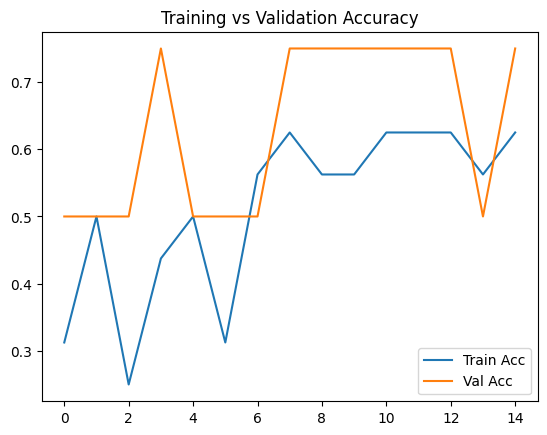


✅ Final Test Accuracy: 75.00%


In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Load labels
df = pd.read_csv("labels.csv")
image_dir = "paper_based_images"
img_size = 128

X, y = [], []

for _, row in df.iterrows():
    img_path = os.path.join(image_dir, row['filename'])
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Could not read {img_path}")
        continue
    img = cv2.resize(img, (img_size, img_size))
    img = img / 255.0
    X.append(img)
    y.append(row['label'])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


# Evaluate final test accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final Test Accuracy: {accuracy*100:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 0.6883 - val_accuracy: 1.0000 - val_loss: 0.4465
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.4444 - loss: 0.8011 - val_accuracy: 0.0000e+00 - val_loss: 2.0652
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step - accuracy: 0.4444 - loss: 0.9395 - val_accuracy: 0.5000 - val_loss: 1.1931
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step - accuracy: 0.4444 - loss: 0.7057 - val_accuracy: 1.0000 - val_loss: 0.4594
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step - accuracy: 0.5556 - loss: 0.7578 - val_accuracy: 1.0000 - val_loss: 0.3959
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step - accuracy: 0.3889 - loss: 0.7911 - val_accuracy: 0.5000 - val_loss: 0.5149
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6392 - val_accuracy: 0.5000 - val_loss: 0.6820
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - accuracy: 0.5000 - loss: 0.5750 - val_accuracy: 0.5000 - val_loss: 0

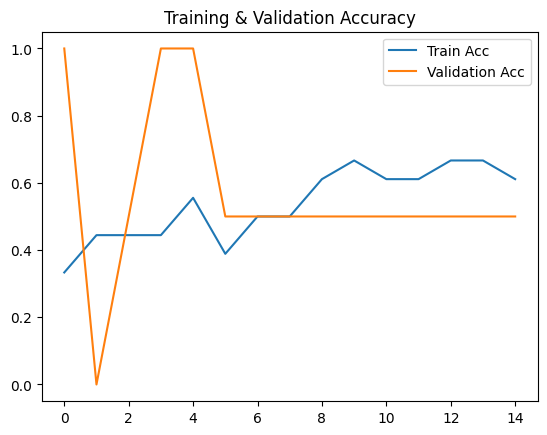

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step

Image No	Predicted_Label	Actual_Label	Prediction_Score
image001.png	NonCancer      NonCancer      0.17
image002.png	NonCancer      NonCancer      0.17
image003.png	NonCancer      NonCancer      0.45
image004.png	NonCancer      NonCancer      0.21
image005.png	NonCancer      NonCancer      0.20
image006.png	Medium         NonCancer      0.53
image007.png	NonCancer      NonCancer      0.31
image008.png	NonCancer      Medium         0.32
image009.png	NonCancer      Medium         0.32
image010.png	Medium         Medium         0.72
image011.png	NonCancer      Medium         0.40
image012.png	Cancer         Medium         0.84
image013.png	NonCancer      Medium         0.50
image014.png	Cancer         Cancer         0.97
image015.png	Cancer         Cancer         0.95
image016.png	Cancer         Cancer         0.85
image017.png	Cancer         Cancer         0.91
image018.png	Cancer         Cancer         0.80
image019.png	Cancer         Cancer       

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
from collections import defaultdict

# Load labels
df = pd.read_csv("labels.csv")
image_dir = "paper_based_images"
img_size = 128

X, y, filenames = [], [], []

# Load all images
for _, row in df.iterrows():
    img_path = os.path.join(image_dir, row['filename'])
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Could not read {img_path}")
        continue
    img = cv2.resize(img, (img_size, img_size))
    img = img / 255.0
    X.append(img)
    y.append(row['label'])
    filenames.append(row['filename'])

X = np.array(X)
y = np.array(y)
filenames = np.array(filenames)

# Build model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with validation
history = model.fit(X, y, epochs=15, verbose=1, validation_split=0.1)

# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

# Predict on all images
y_pred_probs = model.predict(X)
y_pred_labels = []
actual_labels = []

# Map predictions to categories
for prob in y_pred_probs:
    if prob < 0.5:
        y_pred_labels.append("NonCancer")
    elif prob > 0.8:
        y_pred_labels.append("Cancer")
    else:
        y_pred_labels.append("Medium")

# Map true labels
for val in y:
    if val < 0.5:
        actual_labels.append("NonCancer")
    elif val > 0.8:
        actual_labels.append("Cancer")
    else:
        actual_labels.append("Medium")

# Print results
print("\nImage No\tPredicted_Label\tActual_Label\tPrediction_Score")
for i in range(len(filenames)):
    print(f"{filenames[i]}\t{y_pred_labels[i]:<15}{actual_labels[i]:<15}{y_pred_probs[i][0]:.2f}")

correct_count = 0
for i in range(len(filenames)):
    if y_pred_labels[i] == actual_labels[i]:
        correct_count += 1

# Overall prediction accuracy
total = len(filenames)
overall_accuracy = (correct_count / total) * 100
print(f"\n✅ Overall Prediction Accuracy: {overall_accuracy:.2f}% ({correct_count}/{total})")

# Per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)

for i in range(len(actual_labels)):
    class_total[actual_labels[i]] += 1
    if actual_labels[i] == y_pred_labels[i]:
        class_correct[actual_labels[i]] += 1

print("\n📊 Per-Class Accuracy:")
for label in ["NonCancer", "Medium", "Cancer"]:
    total = class_total[label]
    correct = class_correct[label]
    acc = (correct / total * 100) if total > 0 else 0
    print(f"{label:<10}: {acc:.2f}% ({correct}/{total})")


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# Load reference RGB data
ref_files_blue = ["Cysteine_Blue.csv", "Glutathione_Blue.csv", "Sialic_Blue.csv"]
ref_files_red = ["Cysteine_Red.csv", "Glutathione_Red.csv", "Sialic_Red.csv"]
blue_data = []
red_data = []

for file in ref_files_blue:
    df = pd.read_csv(file, header=None)
    intensity_column = df.iloc[:, 1].values
    blue_data.extend(intensity_column)

for file in ref_files_red:
    df = pd.read_csv(file, header=None)
    intensity_column = df.iloc[:, 1].values
    red_data.extend(intensity_column)

ref_blue_mean = np.mean(blue_data)
ref_red_mean = np.mean(red_data)

# Load actual labels
label_df = pd.read_csv("labels.csv")

def get_symbol_regions(image):
    h, w, _ = image.shape
    return {
        'circle': image[int(h*0.15):int(h*0.35), int(w*0.45):int(w*0.55)],
        'pentagon': image[int(h*0.5):int(h*0.7), int(w*0.05):int(w*0.25)],
        'triangle': image[int(h*0.5):int(h*0.7), int(w*0.75):int(w*0.95)],
    }

# Updated classification function
def classify_image(image_path, ref_red_mean, ref_blue_mean, red_threshold=20, blue_threshold=20):
    img = cv2.imread(image_path)
    if img is None:
        return "Error"
    img = cv2.resize(img, (128, 128))
    regions = get_symbol_regions(img)

    red_dominant_count = 0
    blue_dominant_count = 0

    for region in regions.values():
        avg_red = np.mean(region[:, :, 2])
        avg_blue = np.mean(region[:, :, 0])

        if avg_red > ref_red_mean + red_threshold:
            red_dominant_count += 1
        if avg_blue > avg_red + blue_threshold:
            blue_dominant_count += 1

    # Rule 1: Strong Red in all regions → Non-cancer
    if red_dominant_count == 3:
        return "Non-cancer"
    # Rule 2: Majority Blue-dominant → Cancer
    elif blue_dominant_count >= 2:
        return "Cancer"
    # Rule 3: Otherwise → Medium
    else:
        return "Medium"

# Find the best thresholds
best_accuracy = 0
best_red_threshold = 0
best_blue_threshold = 0
for red_threshold in range(0, 50, 5):
    for blue_threshold in range(0, 50, 5):
        correct = 0
        for i in range(1, 21):
            filename = f"image{str(i).zfill(3)}.png"
            path = os.path.join("paper_based_images", filename)

            predicted = classify_image(path, ref_red_mean, ref_blue_mean, red_threshold, blue_threshold)

            actual_row = label_df[label_df['filename'] == filename]
            if not actual_row.empty:
                val = actual_row.iloc[0]['label']
                actual = "Non-cancer" if val == 0 else "Medium" if val == 0.5 else "Cancer" if val == 1 else "Unknown"
            else:
                actual = "Missing"

            if predicted == actual:
                correct += 1
        accuracy = (correct / 20) * 100
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_red_threshold = red_threshold
            best_blue_threshold = blue_threshold

print(f"Best red threshold: {best_red_threshold}")
print(f"Best blue threshold: {best_blue_threshold}")
print(f"Best accuracy: {best_accuracy:.2f}%")

# Evaluate images with the best thresholds
results = []
correct = 0
for i in range(1, 21):
    filename = f"image{str(i).zfill(3)}.png"
    path = os.path.join("paper_based_images", filename)

    predicted = classify_image(path, ref_red_mean, ref_blue_mean, best_red_threshold, best_blue_threshold)

    actual_row = label_df[label_df['filename'] == filename]
    if not actual_row.empty:
        val = actual_row.iloc[0]['label']
        actual = "Non-cancer" if val == 0 else "Medium" if val == 0.5 else "Cancer" if val == 1 else "Unknown"
    else:
        actual = "Missing"

    if predicted == actual:
        correct += 1

    results.append((filename, predicted, actual))

# Results DataFrame
df_results = pd.DataFrame(results, columns=["filename", "predicted_label", "actual_label"])
print(df_results)

# Final accuracy
accuracy = (correct / len(results)) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

Best red threshold: 10
Best blue threshold: 0
Best accuracy: 45.00%
        filename predicted_label actual_label
0   image001.png          Medium   Non-cancer
1   image002.png          Medium   Non-cancer
2   image003.png          Medium   Non-cancer
3   image004.png          Medium   Non-cancer
4   image005.png          Cancer   Non-cancer
5   image006.png          Cancer   Non-cancer
6   image007.png          Cancer   Non-cancer
7   image008.png          Medium       Medium
8   image009.png          Medium       Medium
9   image010.png          Medium       Medium
10  image011.png          Medium       Medium
11  image012.png          Cancer       Medium
12  image013.png          Cancer       Medium
13  image014.png          Medium       Cancer
14  image015.png          Cancer       Cancer
15  image016.png          Cancer       Cancer
16  image017.png          Cancer       Cancer
17  image018.png          Cancer       Cancer
18  image019.png          Medium       Cancer
19  image020